## 1. Import Libraries & Load Dataset

**Tujuan:** Memuat dataset hasil feature selection (`stroke_selected_features.csv`) dari NB05 sebagai basis pengecekan korelasi antar fitur.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/stroke_selected_features.csv')
print(f"Shape: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Kolom: {df.columns.tolist()}")
df.head (10)

Shape: 5094 baris, 7 kolom
Kolom: ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'smoking_status', 'stroke']


,age,avg_glucose_level,bmi,hypertension,heart_disease,smoking_status,stroke
0,67.0,228.69,36.6,0,1,formerly smoked,1
1,80.0,105.92,32.5,0,1,never smoked,1
2,49.0,171.23,34.4,0,0,smokes,1
3,79.0,174.12,24.0,1,0,never smoked,1
4,81.0,186.21,29.0,0,0,formerly smoked,1
5,74.0,70.09,27.4,1,1,never smoked,1
6,69.0,94.39,22.8,0,0,never smoked,1
7,59.0,76.15,28.1,0,0,Unknown,1
8,78.0,58.57,24.2,0,0,Unknown,1
9,81.0,80.43,29.7,1,0,never smoked,1


**Insight:** Dataset hasil feature selection berhasil dimuat dengan shape (5.094 baris, 7 kolom) — 6 fitur final (`age`, `avg_glucose_level`, `bmi`, `hypertension`, `heart_disease`, `smoking_status`) beserta target `stroke`.

## 2. Cek Korelasi Antar Fitur

**Tujuan:** Mengukur seberapa besar fitur-fitur final saling tumpang tindih satu sama lain (bukan terhadap target `stroke`, tapi ANTAR fitur) — untuk membuktikan secara empiris apakah PCA/reduksi dimensi dibutuhkan atau tidak. PCA umumnya diperlukan justru ketika banyak fitur saling redundan (mirip kasus `ever_married`/`work_type` yang sudah dibuang di NB05).

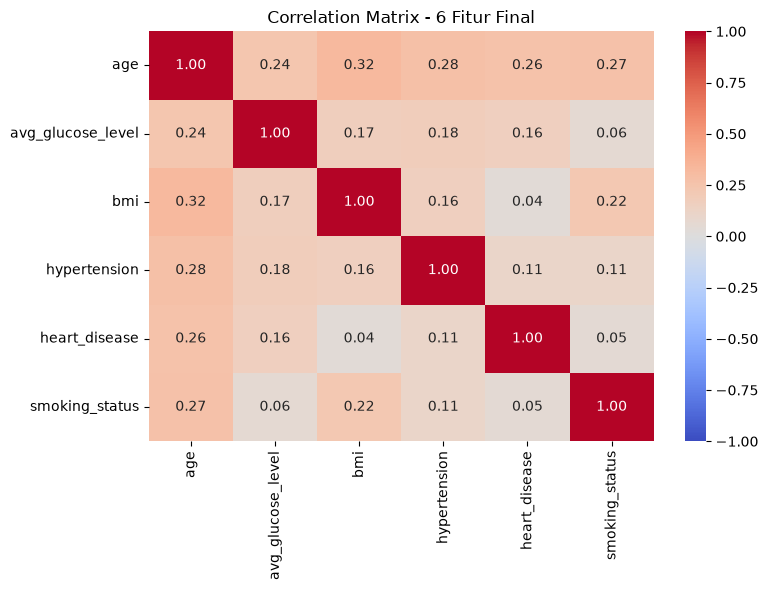

                    age  avg_glucose_level   bmi  hypertension  heart_disease  \
age                1.00               0.24  0.32          0.28           0.26   
avg_glucose_level  0.24               1.00  0.17          0.18           0.16   
bmi                0.32               0.17  1.00          0.16           0.04   
hypertension       0.28               0.18  0.16          1.00           0.11   
heart_disease      0.26               0.16  0.04          0.11           1.00   
smoking_status     0.27               0.06  0.22          0.11           0.05   

                   smoking_status  
age                          0.27  
avg_glucose_level            0.06  
bmi                          0.22  
hypertension                 0.11  
heart_disease                0.05  
smoking_status               1.00  


In [2]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.drop(columns=['stroke']).copy()

le = LabelEncoder()
df_corr['smoking_status'] = le.fit_transform(df_corr['smoking_status'])

corr_matrix = df_corr.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix - 6 Fitur Final')
plt.tight_layout()
plt.show()

print(corr_matrix.round(2))

**Insight:** Korelasi tertinggi antar fitur ditemukan pada pasangan `age`-`bmi` (~0.3), yang masih tergolong lemah-sedang. Tidak ditemukan pasangan fitur dengan korelasi tinggi (>0.7) yang mengindikasikan redundansi parah. Ini menjadi bukti empiris bahwa keenam fitur final relatif tidak saling tumpang tindih, mendukung keputusan untuk tidak menerapkan reduksi dimensi (PCA).

## 3. Justifikasi Keputusan

**Tujuan:** Menyusun argumen lengkap mengapa reduksi dimensi (PCA atau metode sejenis) **tidak diterapkan** pada dataset ini, berdasarkan bukti dari Section 2 dan pertimbangan konteks domain.

**Argumen Keputusan: Reduksi Dimensi TIDAK Diterapkan**

Tiga alasan utama, didukung bukti konkret:

1. **Jumlah fitur sudah minim.** Dataset final hanya memiliki 6 fitur (`age`, `avg_glucose_level`, `bmi`, `hypertension`, `heart_disease`, `smoking_status`) setelah proses feature selection di NB05. PCA umumnya bermanfaat pada dataset dengan puluhan hingga ratusan fitur, di mana kompleksitas komputasi dan risiko *curse of dimensionality* menjadi masalah nyata — kondisi yang tidak berlaku di sini.

2. **Tidak ditemukan multikolinearitas signifikan.** Hasil correlation matrix pada Section 2 menunjukkan korelasi tertinggi antar fitur hanya sekitar 0.3 (`age`-`bmi`), jauh di bawah ambang batas yang umum dianggap mengkhawatirkan (>0.7-0.8). Ini membuktikan secara empiris bahwa fitur-fitur final relatif independen satu sama lain, sehingga tidak ada redundansi informasi yang perlu "dipadatkan" lewat PCA.

3. **PCA mengorbankan interpretability klinis.** PCA mengubah fitur asli menjadi kombinasi linear abstrak (komponen utama) yang kehilangan makna aslinya — misalnya, komponen hasil PCA tidak lagi bisa langsung diartikan sebagai "usia" atau "kadar glukosa". Dalam konteks penelitian kesehatan, kemampuan menjelaskan **fitur mana** yang berkontribusi terhadap risiko stroke jauh lebih bernilai dibanding sedikit efisiensi komputasi yang ditawarkan PCA — apalagi dengan jumlah fitur yang sudah sangat sedikit, efisiensi tersebut nyaris tidak signifikan.

Berdasarkan tiga alasan ini, dataset hasil NB05 (`stroke_selected_features.csv`) akan digunakan langsung tanpa modifikasi lebih lanjut pada tahap visualisasi (NB07) dan persiapan data modeling (NB08).

## 4. Kesimpulan

Berdasarkan analisis pada notebook ini, diputuskan untuk **tidak menerapkan reduksi dimensi** pada dataset stroke prediction. Keputusan ini didasarkan pada kombinasi bukti kuantitatif (jumlah fitur yang sudah minim dan tidak adanya multikolinearitas signifikan antar fitur) dan pertimbangan kualitatif (kebutuhan menjaga interpretability klinis pada penelitian kesehatan). Sesuai arahan tugas bahwa setiap keputusan preprocessing — termasuk keputusan untuk tidak menerapkan suatu teknik — harus disertai argumen yang jelas, notebook ini berfungsi sebagai dokumentasi lengkap atas keputusan tersebut.